## Code de génération du graphe représentant le profile de vitesse saccadé ##

  Accouplement fourche–T — analyse de désalignement
  Demi-écart fourche      R       = 12.5 mm
  Rayon ergot             r       = 1.0 mm
  Rayon effectif          R_eff   = 11.5 mm
  Désalignement simulé    e       = 3.64 mm
  Erreur de vitesse max          = 5.00 %
  Formule : e_max = R_eff · √(2·0.05) = 11.5 · 0.3162


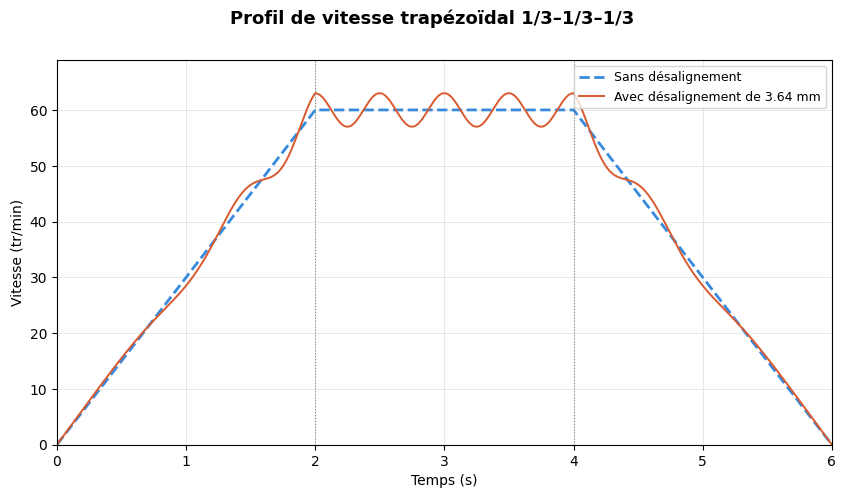

In [11]:
"""
Profil de vitesse trapézoïdal 1/3-1/3-1/3 avec saccade de désalignement
Accouplement fourche-T — prise en compte du rayon des ergots (ø2mm → r=1mm)

Paramètres calqués sur le widget interactif :
  - ω_max      = 60 tr/min
  - Durée T    = 6 s
  - Désalign.  = calculé pour 5 % d'erreur max
  - Demi-écart fourche = 12.5 mm  → R_eff = 12.5 - 1 = 11.5 mm (rayon ergot)
"""

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

# ── Paramètres ────────────────────────────────────────────────────────────────
W_MAX      = 60.0    # vitesse max (tr/min)
T_TOTAL    = 6.0     # durée totale (s)
R_FORK     = 12.5    # demi-espacement fourche (mm)
D_ERGOT    = 2.0     # diamètre des ergots (mm)
THRESHOLD  = 0.05    # seuil d'erreur admissible (5 %)
N          = 3000    # points de simulation

# Rayon effectif : on soustrait le rayon de l'ergot car le contact se fait
# sur le flanc de l'ergot, ce qui réduit le rayon effectif.
R_EFF = R_FORK - D_ERGOT / 2   # = 11.5 mm

# ── Fonctions ─────────────────────────────────────────────────────────────────
def trapezoidal(t, T, w_max):
    """Profil trapézoïdal 1/3-1/3-1/3."""
    t1, t2 = T / 3, 2 * T / 3
    return np.where(
        t <= t1, w_max * t / t1,
        np.where(t <= t2, w_max,
                 np.where(t <= T, w_max * (T - t) / (T - t2), 0.0))
    )

def with_jitter(w_ideal, e, R_eff, t):
    """
    Vitesse avec saccade périodique due au désalignement.
    ε(t) ≈ (e²/2R²) · cos(2θ(t))   avec θ intégré depuis ω(t).
    """
    # Intégration numérique de θ = ∫ω dt  (rad, ω en rad/s)
    omega_rad = w_ideal * 2 * np.pi / 60
    dt = t[1] - t[0]
    theta = np.cumsum(omega_rad) * dt

    factor = 1.0 + (e**2 / (2 * R_eff**2)) * np.cos(2 * theta)
    return w_ideal * factor

def e_max(R_eff, threshold=0.05):
    """Désalignement max pour ne pas dépasser le seuil d'erreur."""
    return R_eff * np.sqrt(2 * threshold)

def max_rel_error(e, R_eff):
    return (e**2) / (2 * R_eff**2) * 100   # en %

# Calculer l'écart pour atteindre exactement 5% d'erreur
E = e_max(R_EFF, THRESHOLD)

# ── Calcul ────────────────────────────────────────────────────────────────────
t = np.linspace(0, T_TOTAL, N)
ideal  = trapezoidal(t, T_TOTAL, W_MAX)
actual = with_jitter(ideal, E, R_EFF, t)

max_err_pct  = max_rel_error(E, R_EFF)

# ── Affichage console ─────────────────────────────────────────────────────────
print("=" * 55)
print("  Accouplement fourche–T — analyse de désalignement")
print("=" * 55)
print(f"  Demi-écart fourche      R       = {R_FORK:.1f} mm")
print(f"  Rayon ergot             r       = {D_ERGOT/2:.1f} mm")
print(f"  Rayon effectif          R_eff   = {R_EFF:.1f} mm")
print(f"  Désalignement simulé    e       = {E:.2f} mm")
print(f"  Erreur de vitesse max          = {max_err_pct:.2f} %")
print(f"  Formule : e_max = R_eff · √(2·0.05) = {R_EFF:.1f} · {np.sqrt(2*THRESHOLD):.4f}")
print("=" * 55)

# ── Figure ────────────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(10, 5))
fig.suptitle(
    "Profil de vitesse trapézoïdal 1/3–1/3–1/3\n",
        fontsize=13, fontweight="bold"
)

# ── Graphe : profils de vitesse ───────────────────────────────────────────────
ax1 = fig.add_subplot(111)
ax1.plot(t, ideal,  color="#378ADD", lw=2.0, ls="--", label="Sans désalignement")
ax1.plot(t, actual, color="#D85A30", lw=1.4,           label=f"Avec désalignement de {E:.2f} mm")

# Zones 1/3
for x, lbl in [(T_TOTAL/3, "Accél."), (2*T_TOTAL/3, "V. cste"), (T_TOTAL, "Décél.")]:
    ax1.axvline(x, color="gray", lw=0.8, ls=":")

ax1.set_xlabel("Temps (s)")
ax1.set_ylabel("Vitesse (tr/min)")
ax1.legend(fontsize=9, loc="upper right")
ax1.set_xlim(0, T_TOTAL)
ax1.set_ylim(0, W_MAX * 1.15)
ax1.grid(True, lw=0.5, alpha=0.4)

plt.show()
